# 🏦 Loan Default Prediction using Naïve Bayes



## 🔁 Workflow

```
Load Data → EDA → Preprocessing → Train/Test Split →
Train Model → Evaluate → Visualize Results
```

##  Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



##  Step 2: Load the Dataset

In [ ]:
df = pd.read_csv('loan_data (1).csv')
# df.shape
df.isnull().sum()
df.dropna(inplace = True)


##  Step 3: Exploratory Data Analysis (EDA)

<Axes: xlabel='loan_status', ylabel='count'>

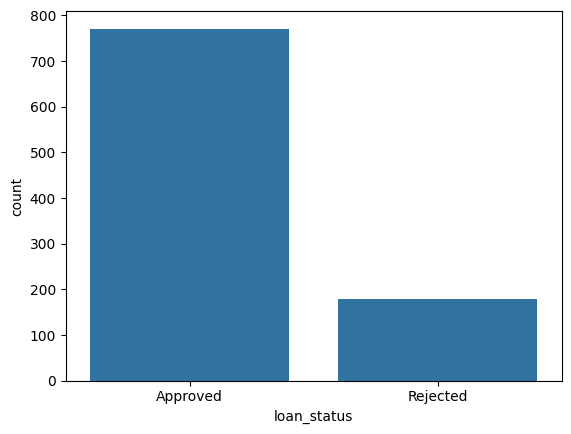

In [ ]:
# Basic info
df.info
# Statistical summary
df.describe()
# Missing values
df.isnull().sum()
# Target variable distribution
df['loan_status'].value_counts()

# Correlation heatmap (numeric columns only)
sns.countplot(data = df, x ='loan_status')

## 🛠️ Step 4: Data Preprocessing

> **Why preprocessing?**  
> Naïve Bayes (GaussianNB) works with **numeric values only**.  
> We need to convert categorical columns (text) into numbers using **Label Encoding/ oneHot Encoding**.

In [ ]:
df_copy = df.copy()
df_copy = df_copy.drop('applicant_id', axis = 1)

In [ ]:
# Identify categorical columns
cat_col = df_copy.select_dtypes(include='object').columns.drop('loan_status')
cat_col

Index(['city', 'education', 'employment_type'], dtype='object')

In [ ]:
# one hot encoding
df_copy = df.copy()
df_copy = pd.get_dummies(df_copy,
                         columns = cat_col,
                         dtype = int,
                         drop_first= True)
df_copy.head(2)
df_copy.shape

(950, 19)

In [ ]:
df_copy = df_copy.drop('applicant_id', axis = 1)


In [ ]:
from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()
df_copy['loan_status'] = Le.fit_transform(df_copy['loan_status'])
df_copy['loan_status'].head()

,loan_status
0,0
1,1
2,0
3,0
4,0


In [ ]:
X = df_copy.drop('loan_status', axis = 1)
y = df_copy['loan_status']


In [ ]:
# Define Features (X) and Target (y)

## ✂️ Step 5: Train-Test Split

> We split the data into **80% training** and **20% testing**.  
> The model **learns from training data** and is **evaluated on test data** it has never seen.

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [ ]:
# Perform class imbalance
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
X_train.shape, y_train.shape

((1048, 17), (1048,))

## 🤖 Step 6: Train the Naïve Bayes Model

> **GaussianNB** assumes features follow a **Normal (Gaussian) distribution**.  
> It calculates the **mean** and **variance** of each feature for each class.

In [ ]:
# Initialize and Train the model
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)


GaussianNB()

In [ ]:
y_pred = gnb.predict(X_test)
y_pred[:10]

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 1])

In [ ]:
compare = pd.DataFrame({
    'Actual' : y_test,
    'Predicted' : y_pred
})
compare.head(10)

,Actual,Predicted
210,0,0
977,0,0
726,0,1
836,1,0
918,0,0
607,0,1
865,0,1
972,0,0
517,1,1
184,0,1


## 📊 Step 7: Model Evaluation

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


In [ ]:
print("\nClassification Report for Navie Bayes:\n")
print(classification_report(y_test, y_pred))


Classification Report for Navie Bayes:

              precision    recall  f1-score   support

           0       0.81      0.39      0.53       247
           1       0.23      0.67      0.34        67

    accuracy                           0.45       314
   macro avg       0.52      0.53      0.43       314
weighted avg       0.69      0.45      0.49       314



## 🔮 Step 8: Predict for a New Loan Applicant

> Let's simulate a **real-world prediction** for a new applicant who has **not been seen by the model** before.

### New Applicant Data

Let's define a new applicant with specific features to see how our model predicts their loan status.

In [ ]:
new_applicant_data = {
    'age': 35,
    'annual_income': 600000,
    'loan_amount': 250000,
    'monthly_emi': 20000,
    'credit_score': 720,
    'months_employed': 60,
    'num_credit_lines': 3,
    'interest_rate': 10.5,
    'loan_term': 36,
    'loan_to_income_ratio': 0.4,
    'debt_to_income_ratio': 0.3,
    'city': 'Mumbai',
    'education': 'Graduate',
    'employment_type': 'Salaried'
}

# Convert to DataFrame
new_applicant_df = pd.DataFrame([new_applicant_data])


new_applicant_processed = pd.get_dummies(new_applicant_df, columns=cat_col, dtype=int)


missing_cols = set(X.columns) - set(new_applicant_processed.columns)
for c in missing_cols:
    new_applicant_processed[c] = 0

extra_cols = set(new_applicant_processed.columns) - set(X.columns)
new_applicant_processed = new_applicant_processed.drop(columns=list(extra_cols))


new_applicant_processed = new_applicant_processed[X.columns]


new_applicant_scaled = scaler.transform(new_applicant_processed)



status_map = {0: 'Approved', 1: 'Rejected'}
predicted_status = status_map[predicted_loan_status[0]]

print(f"The predicted loan status for the new applicant is: {predicted_status}")

The predicted loan status for the new applicant is: Approved


# KNN

### Feature Scaling for KNN

> KNN is sensitive to the scale of the features. We need to standardize the features so that all features contribute equally to the distance calculation.

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Done")


Done


### Train the KNN Model

> We will train a K-Nearest Neighbors classifier on the scaled training data.

In [ ]:
# Initialize KNN classifier with n_neighbors (e.g., 5)

from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=10)

### Make Predictions with KNN

In [ ]:
y_predict=neigh.predict(X_test_scaled)
y_predict[:10]

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
compare=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_predict
})
compare.head(10)

,Actual,Predicted
210,0,0
977,0,1
726,0,1
836,1,0
918,0,0
607,0,0
865,0,0
972,0,0
517,1,0
184,0,0


### Evaluate the KNN Model

> We will evaluate the KNN model using a classification report and confusion matrix to understand its performance.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate KNN Model
# accuracy_knn = accuracy_score(y_test, y_predict)
# precision_knn = precision_score(y_test, y_predict)
# recall_knn = recall_score(y_test, y_predict)
# f1_knn = f1_score(y_test, y_predict)

# print(f"KNN Accuracy: {accuracy_knn:.2f}")
# print(f"KNN Precision: {precision_knn:.2f}")
# print(f"KNN Recall: {recall_knn:.2f}")
# print(f"KNN F1-Score: {f1_knn:.2f}")

print("\nClassification Report for KNN:\n")
print(classification_report(y_test, y_predict))


Classification Report for KNN:

              precision    recall  f1-score   support

           0       0.78      0.82      0.80       247
           1       0.20      0.16      0.18        67

    accuracy                           0.68       314
   macro avg       0.49      0.49      0.49       314
weighted avg       0.66      0.68      0.67       314



### Visualize Confusion Matrix for KNN

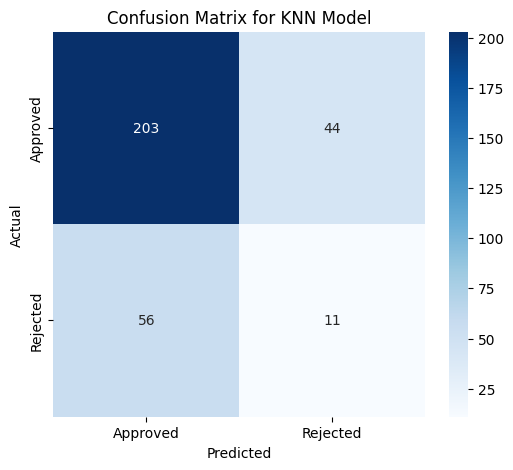

In [ ]:
cm_knn = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Approved', 'Rejected'],
            yticklabels=['Approved', 'Rejected'])
plt.title('Confusion Matrix for KNN Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Elbow Method for Optimal K (K-Means Clustering)



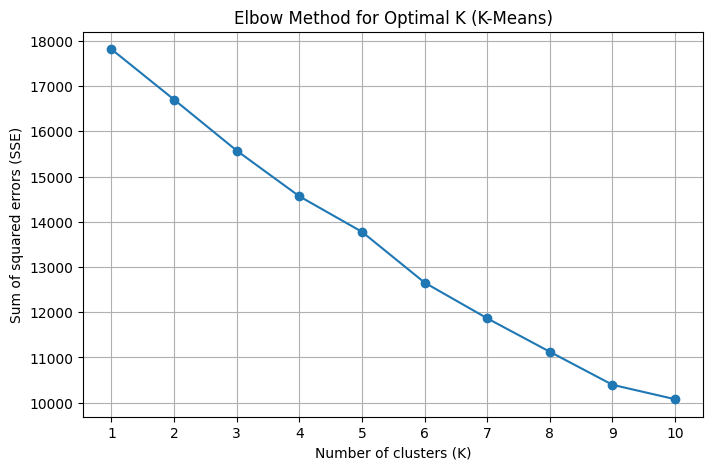

In [ ]:
from sklearn.cluster import KMeans

sse = []
k_range = range(1, 11) # Test K from 1 to 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K (K-Means)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of squared errors (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()